# RSICC Modular Ablation Pipeline

Shared notebook template for all 3 researchers.

- **Shared (do not duplicate):** `src/dataset.py`, `src/training.py`, `src/config.py`
- **Per researcher:** only change the model in Section 3

Copy this notebook as `researcher1_baseline.ipynb`, `researcher2_variant.ipynb`, etc.

## 1. Setup and Imports

In [2]:
import json
from pathlib import Path
from textwrap import shorten

import torch

from src.config import DataConfig, ModelConfig, TrainConfig
from src.dataset import get_levircc_loaders
from src.metrics import (
    SentenceEmbeddingScorer,
    evaluate_model_on_loader,
)
from src.models import RSICCformerBaseline
from src.training import (
    build_criterion,
    build_optimizer_and_scheduler,
    load_checkpoint,
    save_checkpoint,
    train_epoch,
    validate,
    visualize_predictions,
)
from src.utils import get_device, set_seed, setup_project_path

PROJECT_ROOT = setup_project_path()
data_cfg = DataConfig()
model_cfg = ModelConfig()
train_cfg = TrainConfig()
RESEARCHER_NAME = 'researcher1_baseline'  # change per person

data_cfg.checkpoint_dir.mkdir(exist_ok=True)
set_seed(train_cfg.seed)
device = get_device()

print(f'Project root: {PROJECT_ROOT}', flush=True)
print(f'Device: {device}', flush=True)
print('Metrics module loaded: BLEU, METEOR, ROUGE-L, CIDEr, semantic similarity', flush=True)

Project root: /home2/sankalp0109/src_IS


Device: cpu


Metrics module loaded: BLEU, METEOR, ROUGE-L, CIDEr, semantic similarity


/home2/sankalp0109/src_IS/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 2. Load Dataset (Shared by All Researchers)

Every model receives the same batch format:
- `images`: `(B, 2, 3, H, W)` stacked before/after pair
- `caption_tokens`: padded token ids
- `captions`: raw reference strings

In [3]:
train_loader, val_loader, test_loader, vocab = get_levircc_loaders(
    caption_json=data_cfg.caption_json,
    image_root=data_cfg.image_root,
    batch_size=data_cfg.batch_size,
    val_batch_size=data_cfg.val_batch_size,
    device=str(device),
    img_size=data_cfg.img_size,
    min_word_freq=data_cfg.min_word_freq,
    caption_index=data_cfg.caption_index,
    num_workers=data_cfg.num_workers,
    vocab_path=data_cfg.vocab_path,
)

sample_batch = next(iter(train_loader))
print(f'Vocabulary size: {len(vocab.word2idx)}', flush=True)
print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}', flush=True)
print('Batch keys:', sorted(sample_batch.keys()), flush=True)
print('images shape:', sample_batch['images'].shape, flush=True)
print('caption_tokens shape:', sample_batch['caption_tokens'].shape, flush=True)

Vocabulary size: 733


Train batches: 426 | Val: 42 | Test: 61


Batch keys: ['after_images', 'before_images', 'caption_tokens', 'captions', 'changeflags', 'filenames', 'images']


images shape: torch.Size([16, 2, 3, 256, 256])


caption_tokens shape: torch.Size([16, 20])


## 3. Instantiate Your Model

**Researcher 1:** keep `RSICCformerBaseline`.

**Researcher 2 / 3:** replace the model below with your custom class.
Your model must implement:
`forward(images, caption_tokens) -> logits`

In [4]:
# ===== CHANGE ONLY THIS CELL FOR YOUR ABLATION =====
model = RSICCformerBaseline(
    vocab_size=len(vocab.word2idx),
    encoder_dim=model_cfg.encoder_dim,
    embed_dim=model_cfg.embed_dim,
    num_heads=model_cfg.num_heads,
    num_decoder_layers=model_cfg.num_decoder_layers,
    max_caption_len=model_cfg.max_caption_len,
    dropout=model_cfg.dropout,
    encoder_hidden_dim=model_cfg.encoder_hidden_dim,
    pad_idx=vocab.pad_idx,
).to(device)

# Example for a custom variant:
# from src.models.variants.researcher_template import CustomBaselineVariant
# model = CustomBaselineVariant(...).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model: {model.model_name}', flush=True)
print(f'Parameters: {total_params:,}', flush=True)

Model: RSICCformerBaseline


Parameters: 3,405,277


## 4. Train

In [5]:
criterion = build_criterion(vocab)
optimizer, scheduler = build_optimizer_and_scheduler(model, train_cfg)
best_val_loss = float('inf')
start_epoch = 1

checkpoint_path = data_cfg.checkpoint_dir / f'{RESEARCHER_NAME}_current.pt'
if checkpoint_path.exists():
    model, optimizer, last_epoch, loaded_vocab, loaded_loss = load_checkpoint(
        model,
        optimizer,
        checkpoint_path,
        device,
    )
    if loaded_vocab is not None:
        vocab = loaded_vocab
    start_epoch = last_epoch + 1
    if loaded_loss is not None:
        best_val_loss = loaded_loss
    print(f'Resuming training from epoch {start_epoch}', flush=True)
else:
    print('No checkpoint found. Starting training from epoch 1.', flush=True)

for epoch in range(start_epoch, train_cfg.num_epochs + 1):
    train_loss = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
        pad_idx=vocab.pad_idx,
        grad_clip=train_cfg.grad_clip,
        log_every=0,
    )
    val_loss, val_token_acc = validate(
        model,
        val_loader,
        criterion,
        device,
        pad_idx=vocab.pad_idx,
        return_accuracy=True,
    )
    scheduler.step()
    print(
        f'Completed epoch {epoch}/{train_cfg.num_epochs} | '
        f'train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | '
        f'val token acc: {val_token_acc:.2%}',
        flush=True,
    )

    save_checkpoint(
        model=model,
        optimizer=optimizer,
        epoch=epoch,
        loss=val_loss,
        vocab=vocab,
        checkpoint_dir=data_cfg.checkpoint_dir,
        name=RESEARCHER_NAME,
        filename=f'{RESEARCHER_NAME}_current.pt',
        extra={'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'val_token_acc': val_token_acc},
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            loss=val_loss,
            vocab=vocab,
            checkpoint_dir=data_cfg.checkpoint_dir,
            name=RESEARCHER_NAME,
            filename=f'{RESEARCHER_NAME}_best.pt',
            extra={'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss, 'val_token_acc': val_token_acc},
        )

Checkpoint loaded from checkpoints/researcher1_baseline_current.pt


  Epoch: 10, Loss: 1.0854


Resuming training from epoch 11


## 5. Automatic Checkpointing

The training loop saves two rolling checkpoints in `checkpoints/`:
- `RESEARCHER_NAME_current.pt` after every epoch
- `RESEARCHER_NAME_best.pt` whenever validation loss improves

## 6. Inference, Qualitative Samples, and Metrics

Test loss: 0.9690


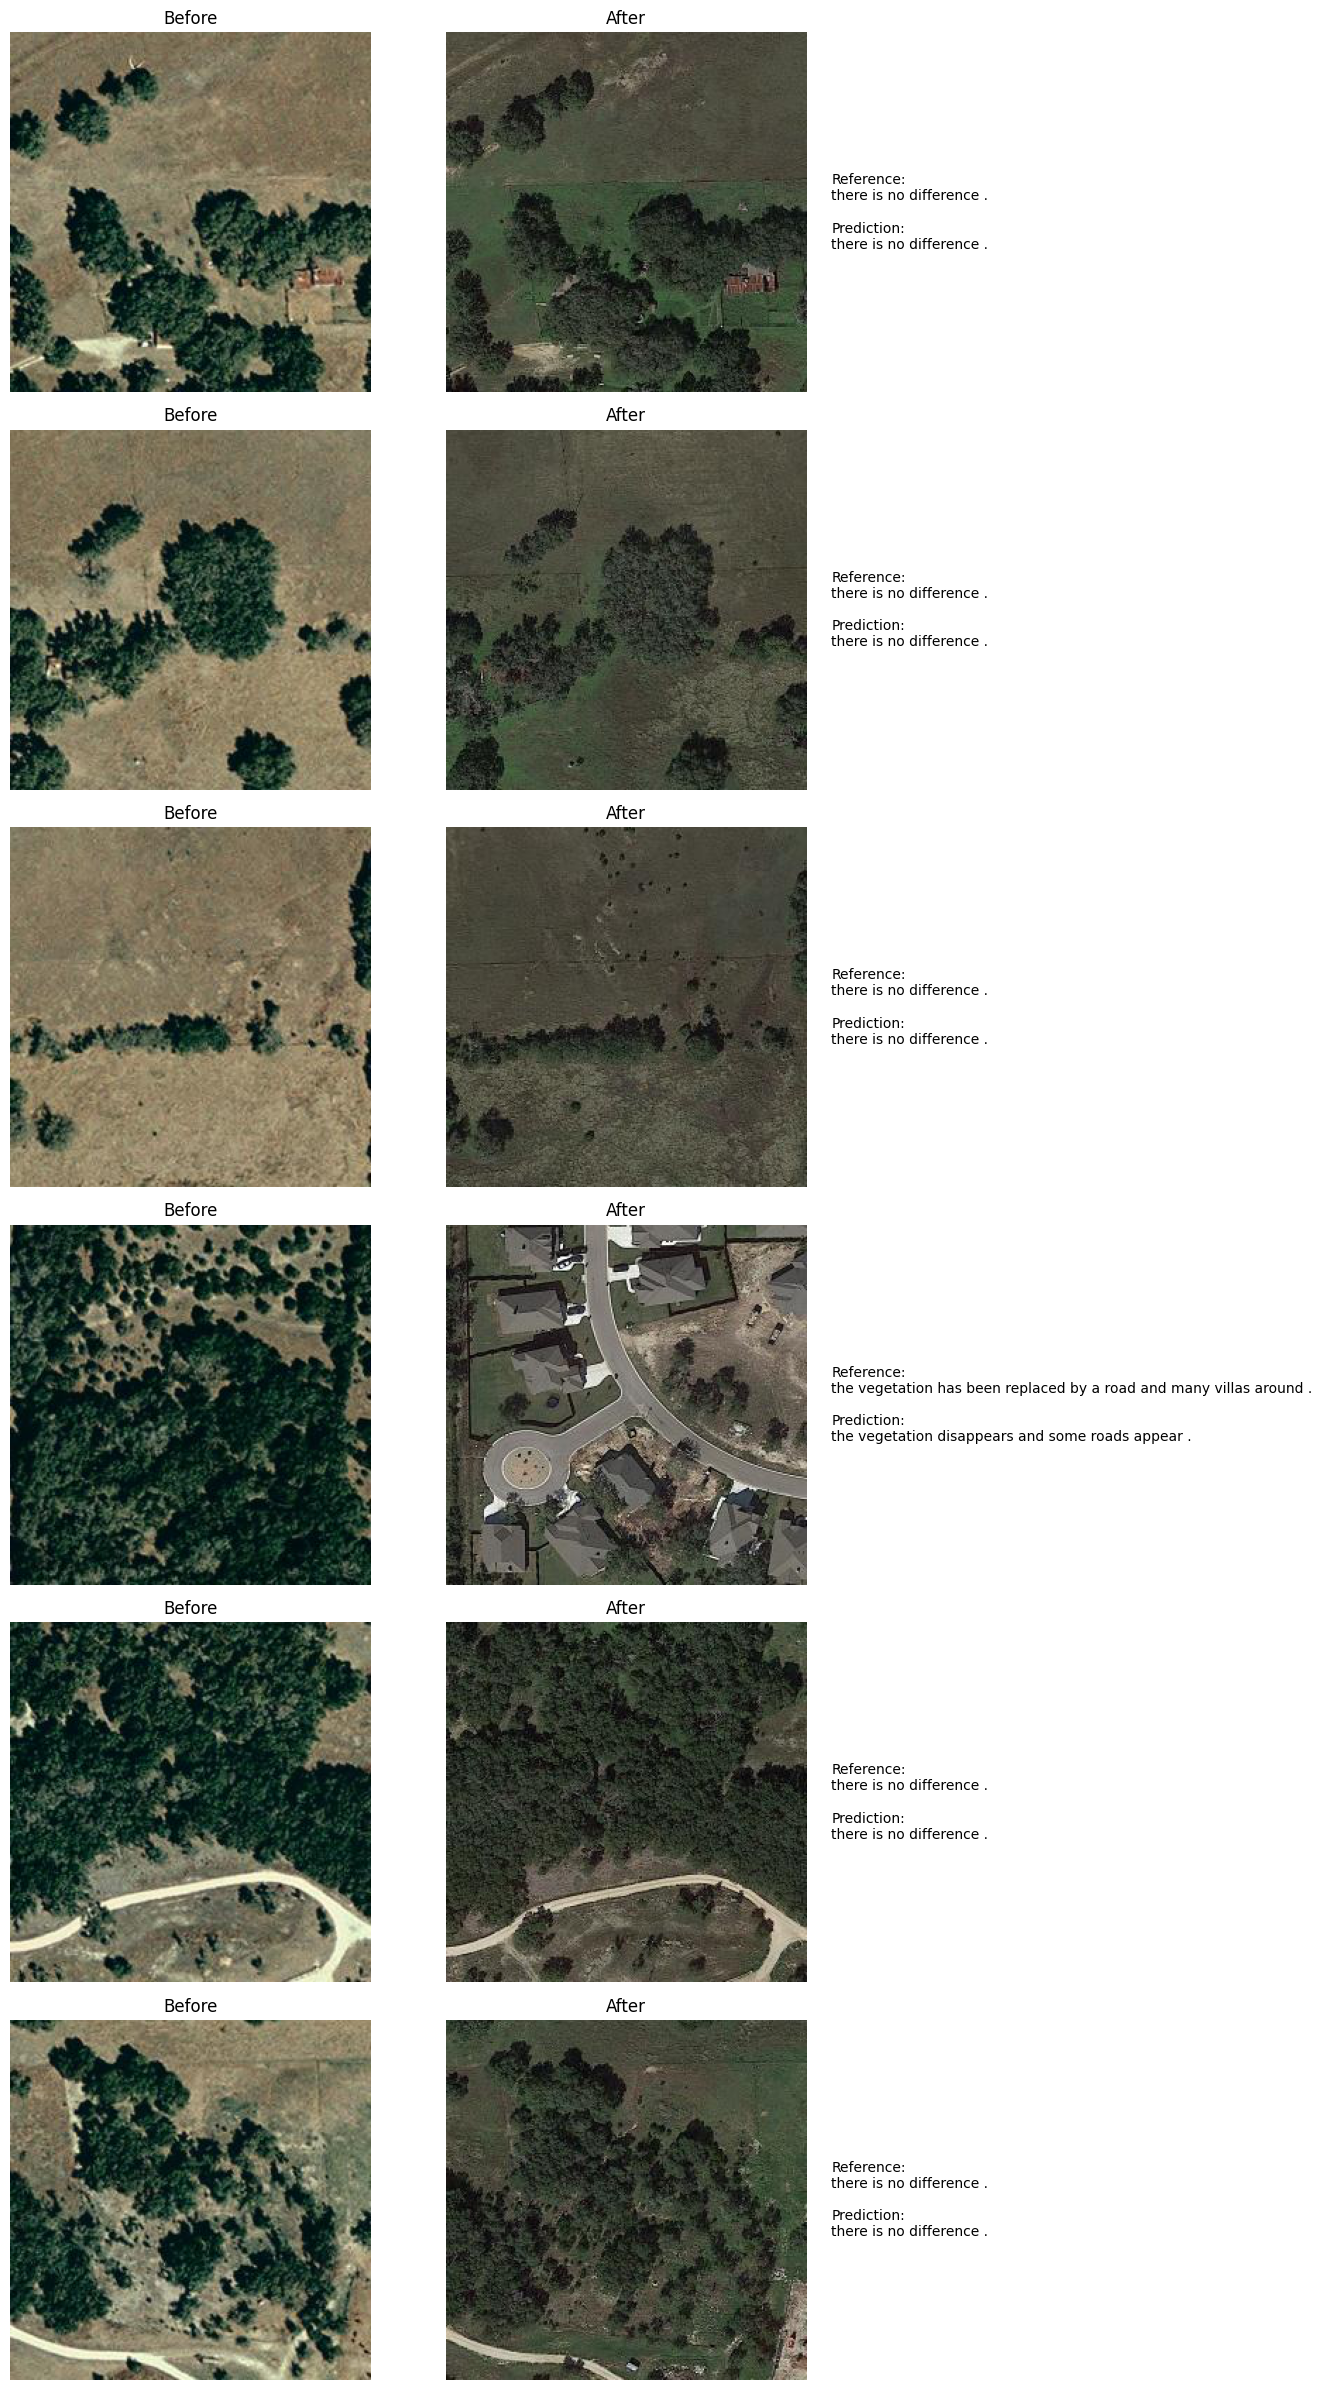

In [ ]:
# Load the best model checkpoint for evaluation
best_path = data_cfg.checkpoint_dir / f'{RESEARCHER_NAME}_best.pt'
if best_path.exists():
    model, _, _, _, _ = load_checkpoint(model, None, best_path, device)
    print(f'Loaded best model from {best_path} for evaluation.', flush=True)

test_loss = validate(model, test_loader, criterion, device, pad_idx=vocab.pad_idx)
print(f'Test loss: {test_loss:.4f}', flush=True)

# Keep qualitative visualization manageable here; detailed 40-sample analysis is below.
visualize_predictions(
    model,
    test_loader,
    vocab,
    device,
    num_samples=300,
    output_pdf="predictions_imagenet.pdf",
    mean=data_cfg.imagenet_mean,
    std=data_cfg.imagenet_std,
)

## 7. Test Set Metrics and 40-Sample Qualitative Report

In [ ]:
# semantic_scorer = SentenceEmbeddingScorer(model_name='all-MiniLM-L6-v2', device=str(device))

# print('Running qualitative evaluation on first 40 test samples...')
# metrics_40, details_40 = evaluate_model_on_loader(
#     model=model,
#     data_loader=test_loader,
#     vocab=vocab,
#     device=device,
#     max_samples=40,
#     semantic_model=semantic_scorer,
# )

# print('\n40-sample metrics:')
# for key, value in metrics_40.items():
#     if key != 'num_samples':
#         print(f'  {key}: {value:.4f}')
# print(f"  num_samples: {metrics_40['num_samples']}")

# print('\n40-sample prediction preview:')
# for idx, item in enumerate(details_40, start=1):
#     ref_text = shorten(item['reference'], width=80, placeholder='...')
#     pred_text = shorten(item['prediction'], width=80, placeholder='...')
#     print(f"[{idx:02d}] {item['filename']} | changeflag={item['changeflag']}\n     REF : {ref_text}\n     PRED: {pred_text}")

# print('\nRunning full test-set evaluation...')
# full_metrics, full_details = evaluate_model_on_loader(
#     model=model,
#     data_loader=test_loader,
#     vocab=vocab,
#     device=device,
#     max_samples=None,
#     semantic_model=semantic_scorer,
# )

# print('\nFull test-set metrics:')
# for key, value in full_metrics.items():
#     if key != 'num_samples':
#         print(f'  {key}: {value:.4f}')
# print(f"  num_samples: {full_metrics['num_samples']}")

# results_path = data_cfg.checkpoint_dir / f'{RESEARCHER_NAME}_test_metrics.json'
# with open(results_path, 'w', encoding='utf-8') as f:
#     json.dump(
#         {
#             'sample_40_metrics': metrics_40,
#             'sample_40_details': details_40,
#             'full_test_metrics': full_metrics,
#             'full_test_count': len(full_details),
#         },
#         f,
#         indent=2,
#         ensure_ascii=False,
#     )
# print(f'\nSaved evaluation summary to: {results_path}')

Running qualitative evaluation on first 40 test samples...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


40-sample metrics:
  BLEU-1: 0.6711
  BLEU-2: 0.5980
  BLEU-3: 0.5489
  BLEU-4: 0.5060
  METEOR: 0.7787
  ROUGE-L: 0.7988
  CIDEr: 7.2715
  Semantic-Similarity: 0.8057
  num_samples: 40

40-sample prediction preview:
[01] test_000001.png | changeflag=0
     REF : there is no difference .
     PRED: there is no difference .
[02] test_000002.png | changeflag=0
     REF : there is no difference .
     PRED: there is no difference .
[03] test_000003.png | changeflag=0
     REF : there is no difference .
     PRED: there is no difference .
[04] test_000004.png | changeflag=1
     REF : the vegetation has been replaced by a road and many villas around .
     PRED: the vegetation disappears and some roads appear .
[05] test_000005.png | changeflag=0
     REF : there is no difference .
     PRED: there is no difference .
[06] test_000006.png | changeflag=0
     REF : there is no difference .
     PRED: there is no difference .
[07] test_000007.png | changeflag=0
     REF : there is no differe


Full test-set metrics:
  BLEU-1: 0.4720
  BLEU-2: 0.3855
  BLEU-3: 0.3393
  BLEU-4: 0.3027
  METEOR: 0.5966
  ROUGE-L: 0.6214
  CIDEr: 5.1296
  Semantic-Similarity: 0.6477
  num_samples: 1929

Saved evaluation summary to: checkpoints/researcher1_baseline_test_metrics.json


## 8. Workflow Summary

1. Copy this notebook for each researcher.
2. Keep Sections 1, 2, 4, 5, 6, and 7 unchanged.
3. Only edit Section 3 to plug in a different architecture.
4. Save checkpoints with unique names in `checkpoints/`.
5. Compare val/test loss, metric scores, and qualitative predictions.